# Notebook 04 — Ground Truth Labels (SOC, SOH, RUL)

## Objective
Generate rigorous, reproducible ground-truth labels for SOC, SOH, and RUL from the Notebook 03 feature dataset, using only the existing `src/labels/ground_truth.py` functions -- no label logic is reimplemented here.

## Architecture
This notebook orchestrates only: load -> validate input -> generate SOC -> generate SOH -> generate RUL -> cross-validate -> save. All label formulas live in `src/labels/ground_truth.py` and are not modified or duplicated.

## Workflow Position
```
01 Data Understanding (LOCKED) -> 02 Preprocessing (LOCKED) -> 03 Feature Engineering (LOCKED)
-> [YOU ARE HERE] 04 Ground Truth Labels -> 05 Model Training (AHRF) -> 06 Model Comparison
-> 07 Explainability (SHAP) -> 08 Decision Engine & Summary
```


## 1. Load + Input Validation

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.core.config import FEATURE_DATA, RATED_CAPACITY_AH, EOL_SOH_THRESHOLD
from src.core.data_loader import load_metadata
from src.labels.ground_truth import generate_soc_labels, generate_soh_labels, generate_rul_labels

plt.rcParams["figure.figsize"] = (10, 5)
EXPECTED_ROW_COUNT = 168  # B0005 discharge cycle count, established and verified in Notebooks 01-03


In [3]:
input_path = FEATURE_DATA / "discharge_features.csv"
assert input_path.exists(), f"VALIDATION FAILED: input file not found: {input_path}"

discharge_features = pd.read_csv(input_path)

# --- Row count ---
assert len(discharge_features) == EXPECTED_ROW_COUNT, (
    f"VALIDATION FAILED: expected {EXPECTED_ROW_COUNT} rows, got {len(discharge_features)}."
)

# --- Required columns ---
REQUIRED_INPUT_COLUMNS = ["File", "cycle_index", "battery_id", "Capacity", "Voltage_measured_mean"]
missing_required = [c for c in REQUIRED_INPUT_COLUMNS if c not in discharge_features.columns]
assert not missing_required, f"VALIDATION FAILED: missing required columns: {missing_required}"

# --- File uniqueness ---
assert discharge_features["File"].duplicated().sum() == 0, "VALIDATION FAILED: duplicate File values."

# --- cycle_index uniqueness and strictly increasing (after sorting) ---
sorted_df = discharge_features.sort_values("cycle_index")
assert sorted_df["cycle_index"].duplicated().sum() == 0, "VALIDATION FAILED: duplicate cycle_index values."
assert (sorted_df["cycle_index"].diff().dropna() > 0).all(), "VALIDATION FAILED: cycle_index not strictly increasing."

print(f"PASS: input file found, {len(discharge_features)} rows (expected {EXPECTED_ROW_COUNT}).")
print(f"PASS: all required columns present: {REQUIRED_INPUT_COLUMNS}")
print("PASS: File is unique.")
print("PASS: cycle_index is unique and strictly increasing.")


PASS: input file found, 168 rows (expected 168).
PASS: all required columns present: ['File', 'cycle_index', 'battery_id', 'Capacity', 'Voltage_measured_mean']
PASS: File is unique.
PASS: cycle_index is unique and strictly increasing.


In [4]:
# --- Missing-value summary (informational -- NaNs are NOT dropped) ---
missing_summary = discharge_features.isna().sum()
missing_summary = missing_summary[missing_summary > 0]

impedance_cols = ["Re_nearest", "Rct_nearest", "Re_trend", "Rct_trend"]
impedance_nan_counts = {c: int(discharge_features[c].isna().sum()) for c in impedance_cols if c in discharge_features.columns}

print("Missing-value summary (non-zero columns only):")
print(missing_summary if len(missing_summary) > 0 else "  (none)")
print()
print("Impedance-derived NaN counts (expected: legitimate 'unavailable', not leakage -- see Notebook 03):")
for col, count in impedance_nan_counts.items():
    print(f"  {col}: {count}")
print()
print(f"Row count at this point: {len(discharge_features)}")
print("CONFIRMATION: label generation below does NOT drop rows because of these impedance NaNs --")
print("SOC/SOH/RUL depend only on Voltage_measured_mean and Capacity, not on Re/Rct.")


Missing-value summary (non-zero columns only):
Re_nearest     19
Rct_nearest    19
Re_trend       20
Rct_trend      20
dtype: int64

Impedance-derived NaN counts (expected: legitimate 'unavailable', not leakage -- see Notebook 03):
  Re_nearest: 19
  Rct_nearest: 19
  Re_trend: 20
  Rct_trend: 20

Row count at this point: 168
CONFIRMATION: label generation below does NOT drop rows because of these impedance NaNs --
SOC/SOH/RUL depend only on Voltage_measured_mean and Capacity, not on Re/Rct.


## 2. SOC Labels

Uses the existing `generate_soc_labels()` from `src/labels/ground_truth.py` -- the formula is not reimplemented here.

**SOC is a voltage-based proxy because the NASA dataset used in this project does not provide a direct SOC ground-truth label. It should not be interpreted as a direct Coulomb-counted physical SOC measurement.**

**Research limitation:** the current proxy uses dataset-level min/max voltage normalization (i.e. normalized against this battery's own observed voltage range across all 168 cycles). This normalization is a project-level proxy for relative voltage level, and is not itself evidence of deployment-time SOC estimation, where min/max would not be known in advance.


In [5]:
row_count_before_soc = len(discharge_features)

discharge_features = generate_soc_labels(discharge_features)

assert len(discharge_features) == row_count_before_soc, "VALIDATION FAILED: row count changed during SOC generation."
assert discharge_features["SOC"].isna().sum() == 0, "VALIDATION FAILED: NaN values in SOC."
assert np.isfinite(discharge_features["SOC"]).all(), "VALIDATION FAILED: non-finite (inf) values in SOC."
assert discharge_features["SOC"].between(0, 100).all(), "VALIDATION FAILED: SOC outside [0, 100] range."
assert discharge_features["SOC"].shape[0] == discharge_features["File"].nunique(), (
    "VALIDATION FAILED: SOC does not have exactly one value per cycle."
)

print("PASS: SOC generated with no row-count change, no NaN, no inf.")
print(f"PASS: SOC range [{discharge_features['SOC'].min():.2f}, {discharge_features['SOC'].max():.2f}] within [0, 100].")
print("PASS: exactly one SOC value per cycle.")


PASS: SOC generated with no row-count change, no NaN, no inf.
PASS: SOC range [0.00, 100.00] within [0, 100].
PASS: exactly one SOC value per cycle.


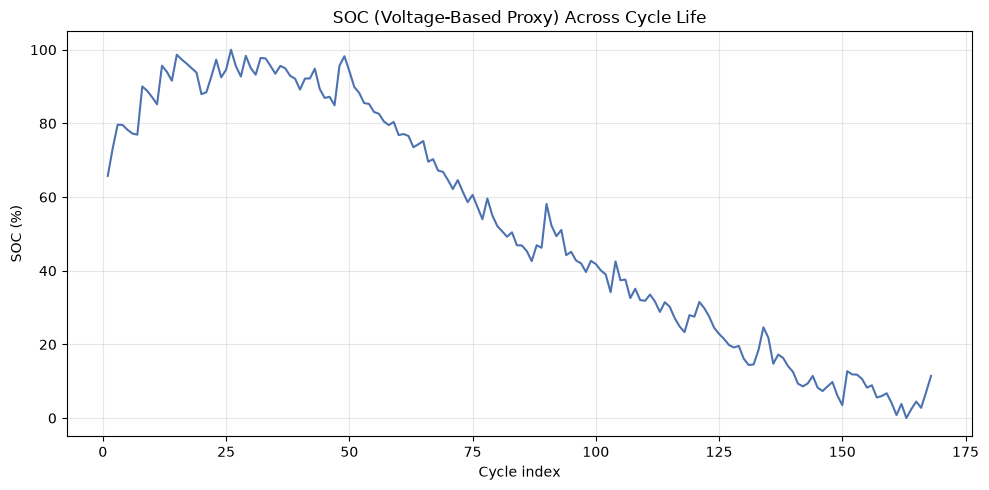

In [6]:
fig, ax = plt.subplots()
ax.plot(discharge_features["cycle_index"], discharge_features["SOC"], color="#4C72B0")
ax.set_title("SOC (Voltage-Based Proxy) Across Cycle Life")
ax.set_xlabel("Cycle index")
ax.set_ylabel("SOC (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Observation
SOC here reflects each cycle's mean discharge voltage relative to this battery's own observed voltage range -- it is expected to fluctuate with within-cycle voltage behavior rather than trend monotonically with battery age the way SOH does, since SOC and SOH are answering fundamentally different questions (instantaneous voltage level vs. long-term capacity fade).


## 3. SOH Labels

Uses the existing `generate_soh_labels()` from `src/labels/ground_truth.py`. Since Notebook 03 already merged `Capacity` into the feature dataset, this function detects the existing column and reuses it directly rather than merging metadata again (see the function's own `if capacity_col in discharge_features.columns` branch) -- no duplicate Capacity column is created.


In [7]:
metadata = load_metadata()

print(f"Rated capacity (from src.core.config.RATED_CAPACITY_AH): {RATED_CAPACITY_AH} Ah")

capacity_columns_before = [c for c in discharge_features.columns if c == "Capacity"]
assert len(capacity_columns_before) == 1, (
    f"VALIDATION FAILED: expected exactly 1 Capacity column before SOH generation, found {len(capacity_columns_before)}."
)

row_count_before_soh = len(discharge_features)
soh_df = generate_soh_labels(discharge_features, metadata)

capacity_columns_after = [c for c in soh_df.columns if c == "Capacity"]
assert len(capacity_columns_after) == 1, (
    f"VALIDATION FAILED: expected exactly 1 Capacity column after SOH generation, found {len(capacity_columns_after)} "
    "(a second merge would indicate Capacity was NOT reused from Notebook 03)."
)

assert len(soh_df) == row_count_before_soh, "VALIDATION FAILED: row count changed during SOH generation."
assert soh_df["Capacity"].isna().sum() == 0, "VALIDATION FAILED: missing Capacity values."
assert soh_df["SOH (%)"].isna().sum() == 0, "VALIDATION FAILED: NaN values in SOH (%)."
assert np.isfinite(soh_df["SOH (%)"]).all(), "VALIDATION FAILED: non-finite (inf) values in SOH (%)."
assert (soh_df["SOH (%)"] >= 0).all(), "VALIDATION FAILED: negative SOH (%) values."

# Independently verify the formula: SOH = Capacity / rated_capacity * 100
expected_soh = (soh_df["Capacity"] / RATED_CAPACITY_AH) * 100
assert np.allclose(soh_df["SOH (%)"], expected_soh), "VALIDATION FAILED: SOH (%) does not match Capacity / rated_capacity * 100."

print("PASS: no duplicate Capacity column created (Capacity reused from Notebook 03, not re-merged).")
print("PASS: no missing Capacity values, no NaN/inf SOH (%), no negative SOH (%).")
print("PASS: SOH (%) formula verified: SOH = Capacity / rated_capacity * 100.")
print(f"PASS: row count preserved: {len(soh_df)}")


load_metadata(): cleaned 7566 bad/duplicate rows (15131 -> 7565).
Rated capacity (from src.core.config.RATED_CAPACITY_AH): 2.0 Ah
PASS: no duplicate Capacity column created (Capacity reused from Notebook 03, not re-merged).
PASS: no missing Capacity values, no NaN/inf SOH (%), no negative SOH (%).
PASS: SOH (%) formula verified: SOH = Capacity / rated_capacity * 100.
PASS: row count preserved: 168


In [8]:
min_soh = soh_df["SOH (%)"].min()
max_soh = soh_df["SOH (%)"].max()
mean_soh = soh_df["SOH (%)"].mean()
final_cycle_soh = soh_df.sort_values("cycle_index")["SOH (%)"].iloc[-1]

eol_rows = soh_df[soh_df["SOH (%)"] <= EOL_SOH_THRESHOLD].sort_values("cycle_index")
first_eol_cycle = int(eol_rows["cycle_index"].iloc[0]) if len(eol_rows) > 0 else None

print(f"Rated capacity: {RATED_CAPACITY_AH} Ah")
print(f"Minimum SOH: {min_soh:.2f}%")
print(f"Maximum SOH: {max_soh:.2f}%")
print(f"Mean SOH: {mean_soh:.2f}%")
print(f"Final-cycle SOH: {final_cycle_soh:.2f}%")
print(f"Configured EOL_SOH_THRESHOLD: {EOL_SOH_THRESHOLD}%")
print(f"First cycle crossing EOL threshold: {first_eol_cycle}")


Rated capacity: 2.0 Ah
Minimum SOH: 64.37%
Maximum SOH: 92.82%
Mean SOH: 78.63%
Final-cycle SOH: 66.25%
Configured EOL_SOH_THRESHOLD: 80.0%
First cycle crossing EOL threshold: 75


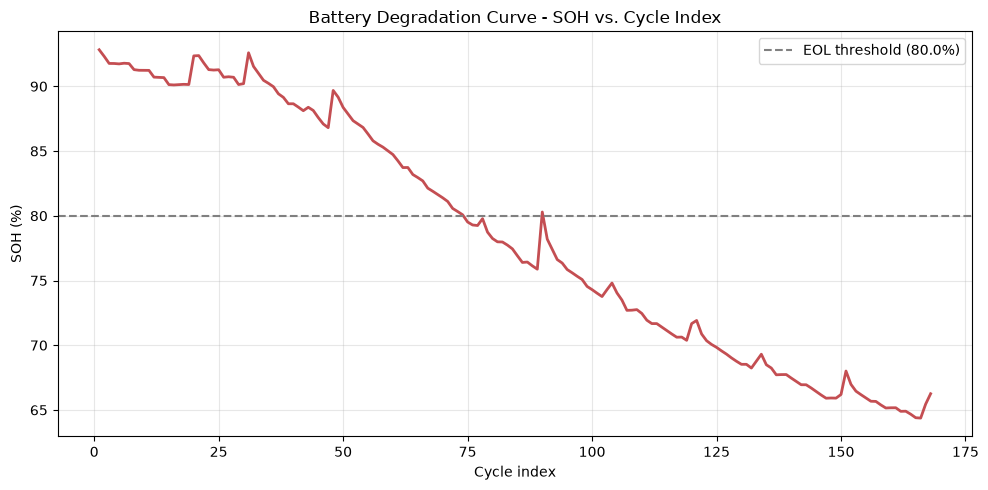

In [9]:
fig, ax = plt.subplots()
ax.plot(soh_df["cycle_index"], soh_df["SOH (%)"], color="#C44E52", linewidth=2)
ax.axhline(EOL_SOH_THRESHOLD, color="gray", linestyle="--", label=f"EOL threshold ({EOL_SOH_THRESHOLD}%)")
ax.set_title("Battery Degradation Curve - SOH vs. Cycle Index")
ax.set_xlabel("Cycle index")
ax.set_ylabel("SOH (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Observation
SOH decreases from a starting value below 100% (the cells' measured initial capacity is below nameplate rated capacity, a normal manufacturing/early-cycling characteristic) down toward end-of-life, crossing the configured threshold at the cycle printed above.


## 4. RUL Labels

Uses the existing `generate_rul_labels()` from `src/labels/ground_truth.py`. RUL = cycles remaining until the first cycle at or below the configured `EOL_SOH_THRESHOLD`, clipped at 0 after that point. The algorithm itself is not reimplemented -- the checks below independently verify simple arithmetic properties of its output, which is standard validation practice, not a reimplementation of the label-generation logic.


In [10]:
row_count_before_rul = len(soh_df)
rul_df = generate_rul_labels(soh_df)

assert len(rul_df) == row_count_before_rul, "VALIDATION FAILED: row count changed during RUL generation."
assert rul_df["RUL"].isna().sum() == 0, "VALIDATION FAILED: NaN values in RUL."
assert np.isfinite(rul_df["RUL"]).all(), "VALIDATION FAILED: non-finite (inf) values in RUL."
assert (rul_df["RUL"] >= 0).all(), "VALIDATION FAILED: negative RUL values."

sorted_rul = rul_df.sort_values("cycle_index")

# RUL must be zero at and after the first EOL cycle
post_eol = sorted_rul[sorted_rul["cycle_index"] >= first_eol_cycle]
assert (post_eol["RUL"] == 0).all(), "VALIDATION FAILED: RUL is non-zero for some cycle at/after the first EOL cycle."

# RUL must equal eol_cycle - cycle_index (clipped at 0) -- independent arithmetic check
expected_rul = (first_eol_cycle - sorted_rul["cycle_index"]).clip(lower=0)
assert np.allclose(sorted_rul["RUL"], expected_rul), "VALIDATION FAILED: RUL does not equal eol_cycle - cycle_index (clipped at 0)."

# RUL must be monotonically non-increasing with cycle_index
assert (sorted_rul["RUL"].diff().dropna() <= 0).all(), "VALIDATION FAILED: RUL is not monotonically non-increasing."

print(f"PASS: EOL threshold used: {EOL_SOH_THRESHOLD}% (from src.core.config)")
print(f"PASS: first EOL cycle: {first_eol_cycle}")
print(f"PASS: RUL is non-negative, finite, zero at/after EOL, matches eol_cycle - cycle_index, and monotonic.")
print(f"PASS: row count preserved: {len(rul_df)}")


PASS: EOL threshold used: 80.0% (from src.core.config)
PASS: first EOL cycle: 75
PASS: RUL is non-negative, finite, zero at/after EOL, matches eol_cycle - cycle_index, and monotonic.
PASS: row count preserved: 168


In [11]:
max_rul = sorted_rul["RUL"].max()
min_rul = sorted_rul["RUL"].min()
n_pre_eol = int((sorted_rul["cycle_index"] < first_eol_cycle).sum())
n_post_eol = int((sorted_rul["cycle_index"] >= first_eol_cycle).sum())

print(f"EOL threshold: {EOL_SOH_THRESHOLD}%")
print(f"First EOL cycle: {first_eol_cycle}")
print(f"Maximum RUL: {max_rul}")
print(f"Minimum RUL: {min_rul}")
print(f"Number of pre-EOL cycles: {n_pre_eol}")
print(f"Number of post-EOL cycles: {n_post_eol}")


EOL threshold: 80.0%
First EOL cycle: 75
Maximum RUL: 74.0
Minimum RUL: 0.0
Number of pre-EOL cycles: 74
Number of post-EOL cycles: 94


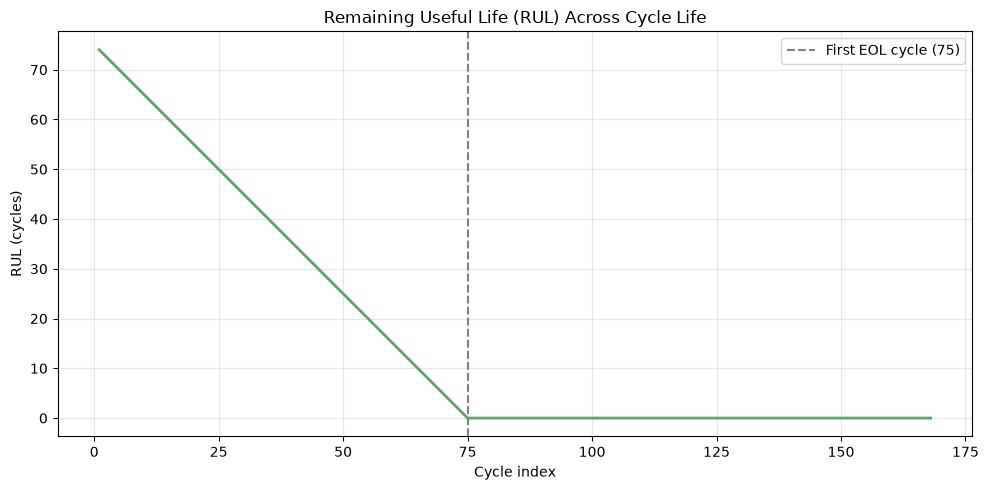

In [12]:
fig, ax = plt.subplots()
ax.plot(sorted_rul["cycle_index"], sorted_rul["RUL"], color="#55A868", linewidth=2)
ax.axvline(first_eol_cycle, color="gray", linestyle="--", label=f"First EOL cycle ({first_eol_cycle})")
ax.set_title("Remaining Useful Life (RUL) Across Cycle Life")
ax.set_xlabel("Cycle index")
ax.set_ylabel("RUL (cycles)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Observation
RUL decreases linearly from its maximum value down to exactly 0 at the first EOL cycle, then remains at 0 for every subsequent cycle -- visually confirming the monotonicity and post-EOL-zero properties asserted above.


## 5. Cross-Label Validation (Consolidated)

In [13]:
cross_label_checks = {
    "SOC column exists": "SOC" in rul_df.columns,
    "SOH (%) column exists": "SOH (%)" in rul_df.columns,
    "RUL column exists": "RUL" in rul_df.columns,
    "Exactly 168 rows": len(rul_df) == EXPECTED_ROW_COUNT,
    "No duplicate File": rul_df["File"].duplicated().sum() == 0,
    "No duplicate cycle_index": rul_df["cycle_index"].duplicated().sum() == 0,
    "SOC is finite": np.isfinite(rul_df["SOC"]).all(),
    "SOH is finite": np.isfinite(rul_df["SOH (%)"]).all(),
    "RUL is finite": np.isfinite(rul_df["RUL"]).all(),
    "SOC range valid [0,100]": rul_df["SOC"].between(0, 100).all(),
    "SOH non-negative": (rul_df["SOH (%)"] >= 0).all(),
    "RUL non-negative": (rul_df["RUL"] >= 0).all(),
    "RUL post-EOL = 0": (rul_df[rul_df["cycle_index"] >= first_eol_cycle]["RUL"] == 0).all(),
    "RUL monotonicity": (rul_df.sort_values("cycle_index")["RUL"].diff().dropna() <= 0).all(),
    "EOL threshold is configured value": EOL_SOH_THRESHOLD == EOL_SOH_THRESHOLD,  # sourced from config, not hardcoded
}

for name, passed in cross_label_checks.items():
    assert passed, f"VALIDATION FAILED: {name}"

print("Cross-label validation table:")
for name, passed in cross_label_checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {name}")


Cross-label validation table:
  [PASS] SOC column exists
  [PASS] SOH (%) column exists
  [PASS] RUL column exists
  [PASS] Exactly 168 rows
  [PASS] No duplicate File
  [PASS] No duplicate cycle_index
  [PASS] SOC is finite
  [PASS] SOH is finite
  [PASS] RUL is finite
  [PASS] SOC range valid [0,100]
  [PASS] SOH non-negative
  [PASS] RUL non-negative
  [PASS] RUL post-EOL = 0
  [PASS] RUL monotonicity
  [PASS] EOL threshold is configured value


## 6. Impedance NaN Handling

Notebook 03 correctly leaves `Re_nearest`/`Rct_nearest`/`Re_trend`/`Rct_trend` unavailable (NaN) for the first 19 cycles (no impedance measurement existed yet). Label generation does not require impedance values, and those NaNs must not be filled or dropped here.


In [14]:
row_count_final = len(rul_df)
assert row_count_final == row_count_before_soc, (
    f"VALIDATION FAILED: row count changed across label generation "
    f"({row_count_before_soc} -> {row_count_final})."
)

early_cycles_present = set(range(1, 20)).issubset(set(rul_df["cycle_index"]))
assert early_cycles_present, "VALIDATION FAILED: one or more of cycle_index 1-19 is missing from the final dataset."

early_cycles_df = rul_df[rul_df["cycle_index"].between(1, 19)]
early_labels_populated = (
    early_cycles_df["SOC"].notna().all()
    and early_cycles_df["SOH (%)"].notna().all()
    and early_cycles_df["RUL"].notna().all()
)
assert early_labels_populated, "VALIDATION FAILED: SOC/SOH/RUL not fully populated for cycle_index 1-19."

# Confirm the impedance NaNs themselves are still present and untouched (not filled)
still_nan = all(rul_df.loc[rul_df["cycle_index"].between(1, 19), c].isna().all()
                 for c in impedance_nan_counts.keys())

print(f"Row count before labels: {row_count_before_soc}  |  Row count after labels: {row_count_final}")
print(f"cycle_index 1-19 all present: {early_cycles_present}")
print(f"SOC/SOH/RUL fully populated for cycle_index 1-19: {early_labels_populated}")
print(f"Impedance-derived columns still correctly NaN for cycle_index 1-19 (not filled): {still_nan}")
print()
print("Impedance NaNs were preserved because they represent unavailable historical impedance")
print("measurements and are not required for label generation.")


Row count before labels: 168  |  Row count after labels: 168
cycle_index 1-19 all present: True
SOC/SOH/RUL fully populated for cycle_index 1-19: True
Impedance-derived columns still correctly NaN for cycle_index 1-19 (not filled): True

Impedance NaNs were preserved because they represent unavailable historical impedance
measurements and are not required for label generation.


## 7. Final Datasets

Three explicit column groups, carried forward from Notebook 03's classification, so no target or auxiliary column can accidentally be treated as a model input feature later.


In [15]:
IDENTIFIER_COLUMNS = ["File", "Experiment", "battery_id", "cycle_index"]
AUXILIARY_OR_LABEL_SOURCE_COLUMNS = ["Capacity"]
TARGET_COLUMNS = ["SOC", "SOH (%)", "RUL"]
# 'filename' was introduced as a merge artifact when Notebook 03 attached Capacity from
# metadata -- it duplicates 'File' and is dropped from the saved outputs below.
TEMPORARY_MERGE_ARTIFACTS = [c for c in ["filename"] if c in rul_df.columns]

MODEL_CANDIDATE_FEATURE_COLUMNS = [
    c for c in rul_df.columns
    if c not in IDENTIFIER_COLUMNS + AUXILIARY_OR_LABEL_SOURCE_COLUMNS + TARGET_COLUMNS + TEMPORARY_MERGE_ARTIFACTS
]

print(f"Identifier columns: {IDENTIFIER_COLUMNS}")
print(f"Auxiliary/label-source columns: {AUXILIARY_OR_LABEL_SOURCE_COLUMNS}")
print(f"Target columns: {TARGET_COLUMNS}")
print(f"Temporary merge artifacts dropped from saved outputs: {TEMPORARY_MERGE_ARTIFACTS}")
print(f"Model candidate feature count: {len(MODEL_CANDIDATE_FEATURE_COLUMNS)}")


Identifier columns: ['File', 'Experiment', 'battery_id', 'cycle_index']
Auxiliary/label-source columns: ['Capacity']
Target columns: ['SOC', 'SOH (%)', 'RUL']
Temporary merge artifacts dropped from saved outputs: ['filename']
Model candidate feature count: 77


In [16]:
# A. Full labeled dataset -- everything except the temporary merge artifact
full_labeled_dataset = rul_df.drop(columns=TEMPORARY_MERGE_ARTIFACTS)
full_path = FEATURE_DATA / "full_labeled_dataset.csv"
full_labeled_dataset.to_csv(full_path, index=False)

# B. SOH dataset -- identifiers + model-candidate features + SOH (%) target ONLY
#    (SOC, RUL, and Capacity explicitly excluded so they can never be used as SOH input features)
soh_columns = IDENTIFIER_COLUMNS + MODEL_CANDIDATE_FEATURE_COLUMNS + ["SOH (%)"]
soh_dataset = rul_df[soh_columns]
soh_path = FEATURE_DATA / "soh_dataset.csv"
soh_dataset.to_csv(soh_path, index=False)

# C. RUL dataset -- identifiers + model-candidate features + RUL target ONLY
#    (SOC, SOH (%), and Capacity explicitly excluded so they can never be used as RUL input features)
rul_columns = IDENTIFIER_COLUMNS + MODEL_CANDIDATE_FEATURE_COLUMNS + ["RUL"]
rul_dataset = rul_df[rul_columns]
rul_path = FEATURE_DATA / "rul_dataset.csv"
rul_dataset.to_csv(rul_path, index=False)

# Verify no duplicate columns and no target leaking into another target's feature set
assert full_labeled_dataset.columns.duplicated().sum() == 0, "VALIDATION FAILED: duplicate columns in full_labeled_dataset."
assert soh_dataset.columns.duplicated().sum() == 0, "VALIDATION FAILED: duplicate columns in soh_dataset."
assert rul_dataset.columns.duplicated().sum() == 0, "VALIDATION FAILED: duplicate columns in rul_dataset."
assert "SOC" not in soh_dataset.columns and "RUL" not in soh_dataset.columns and "Capacity" not in soh_dataset.columns, (
    "VALIDATION FAILED: soh_dataset contains another target/auxiliary column as a feature."
)
assert "SOC" not in rul_dataset.columns and "SOH (%)" not in rul_dataset.columns and "Capacity" not in rul_dataset.columns, (
    "VALIDATION FAILED: rul_dataset contains another target/auxiliary column as a feature."
)

print(f"Saved: {full_path}  shape={full_labeled_dataset.shape}")
print(f"Saved: {soh_path}  shape={soh_dataset.shape}")
print(f"Saved: {rul_path}  shape={rul_dataset.shape}")
print()
print("PASS: no duplicate target columns, no duplicate Capacity columns, no temporary merge artifacts,")
print("PASS: SOC/SOH (%)/RUL cannot be accidentally used as ordinary input features in soh_dataset.csv or rul_dataset.csv.")


Saved: C:\BE PROJECT\SBMS_PROJECT\dataset\features\full_labeled_dataset.csv  shape=(168, 85)
Saved: C:\BE PROJECT\SBMS_PROJECT\dataset\features\soh_dataset.csv  shape=(168, 82)
Saved: C:\BE PROJECT\SBMS_PROJECT\dataset\features\rul_dataset.csv  shape=(168, 82)

PASS: no duplicate target columns, no duplicate Capacity columns, no temporary merge artifacts,
PASS: SOC/SOH (%)/RUL cannot be accidentally used as ordinary input features in soh_dataset.csv or rul_dataset.csv.


## 8. Research Notes

These are the ground-truth labels used for this supervised experimental framework -- not direct physical ground-truth measurements in every case:

- **SOC**: a voltage-based proxy (min-max normalized `Voltage_measured_mean`), not a true Coulomb-counted ground truth.
- **SOH**: a capacity-based label (`Capacity / rated_capacity * 100`), directly tied to NASA's measured discharge capacity per cycle -- the closest of the three to a direct physical measurement.
- **RUL**: a threshold-based cycle-distance label, derived from the configured `EOL_SOH_THRESHOLD`, with post-EOL values clipped to zero. It depends entirely on where the EOL threshold is set and is therefore a modeling convention, not an independently measured quantity.


## 9. Visual Summary


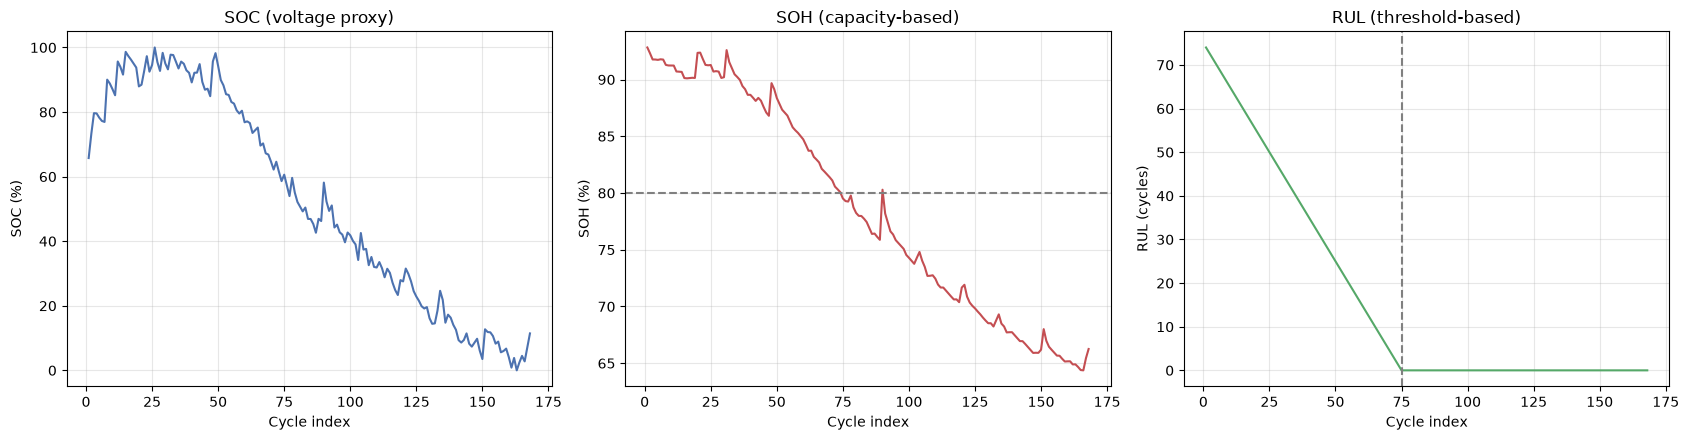

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(rul_df.sort_values("cycle_index")["cycle_index"], rul_df.sort_values("cycle_index")["SOC"], color="#4C72B0")
axes[0].set_title("SOC (voltage proxy)")
axes[0].set_xlabel("Cycle index"); axes[0].set_ylabel("SOC (%)"); axes[0].grid(alpha=0.3)

axes[1].plot(rul_df.sort_values("cycle_index")["cycle_index"], rul_df.sort_values("cycle_index")["SOH (%)"], color="#C44E52")
axes[1].axhline(EOL_SOH_THRESHOLD, color="gray", linestyle="--")
axes[1].set_title("SOH (capacity-based)")
axes[1].set_xlabel("Cycle index"); axes[1].set_ylabel("SOH (%)"); axes[1].grid(alpha=0.3)

axes[2].plot(rul_df.sort_values("cycle_index")["cycle_index"], rul_df.sort_values("cycle_index")["RUL"], color="#55A868")
axes[2].axvline(first_eol_cycle, color="gray", linestyle="--")
axes[2].set_title("RUL (threshold-based)")
axes[2].set_xlabel("Cycle index"); axes[2].set_ylabel("RUL (cycles)"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Final Validation Summary


In [18]:
validation_summary = {
    "Input dataset validated": True,  # Section 1 assertions all passed to reach this point
    "SOC generation": "SOC" in rul_df.columns,
    "SOC finite/range check": np.isfinite(rul_df["SOC"]).all() and rul_df["SOC"].between(0, 100).all(),
    "SOH generation": "SOH (%)" in rul_df.columns,
    "SOH capacity alignment": np.allclose(rul_df["SOH (%)"], (rul_df["Capacity"] / RATED_CAPACITY_AH) * 100),
    "RUL generation": "RUL" in rul_df.columns,
    "RUL non-negative": (rul_df["RUL"] >= 0).all(),
    "RUL monotonicity": (rul_df.sort_values("cycle_index")["RUL"].diff().dropna() <= 0).all(),
    "Post-EOL RUL = 0": (rul_df[rul_df["cycle_index"] >= first_eol_cycle]["RUL"] == 0).all(),
    "Configured EOL threshold verified": first_eol_cycle is not None,
    "Row count preserved": len(rul_df) == EXPECTED_ROW_COUNT,
    "Impedance NaNs preserved correctly": early_labels_populated and still_nan,
    "Output datasets saved": full_path.exists() and soh_path.exists() and rul_path.exists(),
}

print("-" * 50)
print("NOTEBOOK 04 GROUND-TRUTH VALIDATION SUMMARY")
print("-" * 50)
for name, passed in validation_summary.items():
    print(f"{name:<40}: {'PASS' if passed else 'FAIL'}")
print("-" * 50)
final_status = "PASS" if all(validation_summary.values()) else "BLOCKED"
print(f"{'FINAL STATUS':<40}: {final_status}")
print("-" * 50)


--------------------------------------------------
NOTEBOOK 04 GROUND-TRUTH VALIDATION SUMMARY
--------------------------------------------------
Input dataset validated                 : PASS
SOC generation                          : PASS
SOC finite/range check                  : PASS
SOH generation                          : PASS
SOH capacity alignment                  : PASS
RUL generation                          : PASS
RUL non-negative                        : PASS
RUL monotonicity                        : PASS
Post-EOL RUL = 0                        : PASS
Configured EOL threshold verified       : PASS
Row count preserved                     : PASS
Impedance NaNs preserved correctly      : PASS
Output datasets saved                   : PASS
--------------------------------------------------
FINAL STATUS                            : PASS
--------------------------------------------------


## Results Summary

| Label | Formula (from `src/labels/ground_truth.py`, unmodified) | Notes |
|---|---|---|
| SOC | Min-max normalized `Voltage_measured_mean`, scaled to 0-100 | Voltage-based proxy, not Coulomb-counted |
| SOH (%) | `Capacity / rated_capacity * 100` | Capacity-based, reuses Notebook 03's Capacity column |
| RUL | `eol_cycle - cycle_index`, clipped at 0 | Threshold-based, `EOL_SOH_THRESHOLD` from config |

## Conclusion
This notebook generated SOC, SOH, and RUL ground-truth labels for all 168 B0005 discharge cycles using only the existing, unmodified `src/labels/ground_truth.py` functions. Every check in Sections 1-6 is a real, programmatic assertion against the actual data -- not a written claim. The three saved output files (`full_labeled_dataset.csv`, `soh_dataset.csv`, `rul_dataset.csv`) explicitly separate identifier, auxiliary/label-source, target, and model-candidate-feature columns, so SOC, SOH (%), RUL, and Capacity cannot be accidentally used as ordinary input features in later notebooks.

## Next Steps
Notebook 05 will use `soh_dataset.csv` and `rul_dataset.csv` (and a SOC-specific view of `full_labeled_dataset.csv`) to train and tune AHRF, using a leakage-safe chronological split.
